In [1]:
pip install numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [8]:
file_path=r"C:\Users\rinku\Downloads\archive\Bengaluru_House_Data.csv"
df=pd.read_csv(file_path)
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [10]:
df.shape

(13320, 9)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [12]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [13]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

## Data Cleaning

💰 Price (in Lakhs):
   - Min  →   8 Lakhs
   - Max  → 3600 Lakhs  ← 🚨 Outlier!
   - Mean →  112 Lakhs
   - 75%  →  120 Lakhs  (most houses below 120L)

🛁 Bath:
   - Max → 40 bathrooms 🚨 Outlier! (impossible for normal house)

🏠 Balcony:
   - Max → 3 (looks fine ✅)

In [14]:
df = df.drop(['area_type', 'availability', 'society', 'balcony'], axis=1)

print(df.shape)
print(df.head())

(13320, 5)
                   location       size total_sqft  bath   price
0  Electronic City Phase II      2 BHK       1056   2.0   39.07
1          Chikka Tirupathi  4 Bedroom       2600   5.0  120.00
2               Uttarahalli      3 BHK       1440   2.0   62.00
3        Lingadheeranahalli      3 BHK       1521   3.0   95.00
4                  Kothanur      2 BHK       1200   2.0   51.00


In [15]:
print(df['size'].unique())

['2 BHK' '4 Bedroom' '3 BHK' '4 BHK' '6 Bedroom' '3 Bedroom' '1 BHK'
 '1 RK' '1 Bedroom' '8 Bedroom' '2 Bedroom' '7 Bedroom' '5 BHK' '7 BHK'
 '6 BHK' '5 Bedroom' '11 BHK' '9 BHK' nan '9 Bedroom' '27 BHK'
 '10 Bedroom' '11 Bedroom' '10 BHK' '19 BHK' '16 BHK' '43 Bedroom'
 '14 BHK' '8 BHK' '12 Bedroom' '13 BHK' '18 Bedroom']


## Fixing Size Column

In [17]:
print(df['size'].isnull().sum())

16


In [18]:
df = df.dropna()

In [20]:
print(df.isnull().sum())
print(df.shape)

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64
(13246, 5)


In [21]:
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))

print(df['bhk'].unique())
print(df[['size','bhk']].head())

[ 2  4  3  6  1  8  7  5 11  9 27 10 19 16 43 14 12 13 18]
        size  bhk
0      2 BHK    2
1  4 Bedroom    4
2      3 BHK    3
3      3 BHK    3
4      2 BHK    2


In [24]:
print(df.head())
print(df.shape)

                   location total_sqft  bath   price  bhk
0  Electronic City Phase II       1056   2.0   39.07    2
1          Chikka Tirupathi       2600   5.0  120.00    4
2               Uttarahalli       1440   2.0   62.00    3
3        Lingadheeranahalli       1521   3.0   95.00    3
4                  Kothanur       1200   2.0   51.00    2
(13246, 5)


## Fixing SQFT Column

In [26]:
print(df['total_sqft'].unique())

['1056' '2600' '1440' ... '1133 - 1384' '774' '4689']


In [27]:
# Simple function
def convert_sqft(x):
    if '-' in x:   # If value is a range
        a, b = x.split('-')
        return (float(a) + float(b)) / 2
    try:
        return float(x)   # Normal number
    except:
        return None       # Invalid values

# Apply function
df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

# Remove rows where conversion failed
df = df[df['total_sqft'].notnull()]

# Check result
print(df['total_sqft'].dtype)
print(df.shape)
df.head()

float64
(13200, 5)


,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056.0,2.0,39.07,2
1,Chikka Tirupathi,2600.0,5.0,120.00,4
2,Uttarahalli,1440.0,2.0,62.00,3
3,Lingadheeranahalli,1521.0,3.0,95.00,3
4,Kothanur,1200.0,2.0,51.00,2


# Feature Engineering

✅ Create New Feature → price_per_sqft

In [29]:
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']
df.head()

,location,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,1200.0,2.0,51.00,2,4250.000000


In [30]:
df['price_per_sqft'].describe()

count    1.320000e+04
mean     7.920759e+03
std      1.067272e+05
min      2.678298e+02
25%      4.267701e+03
50%      5.438331e+03
75%      7.317073e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

### Remove BHK Size Outliers (300 sqft rule)

In [31]:
df = df[df['total_sqft'] / df['bhk'] >= 300]
print(df.shape)

(12456, 6)


## Remove Price Per Sqft Outliers (Location-wise)

In [32]:
def remove_pps_outliers(data):
    df_out = pd.DataFrame()
    
    for location, subdf in data.groupby('location'):
        mean = subdf.price_per_sqft.mean()
        std = subdf.price_per_sqft.std()
        
        reduced_df = subdf[
            (subdf.price_per_sqft > (mean - std)) &
            (subdf.price_per_sqft <= (mean + std))
        ]
        
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    
    return df_out

df = remove_pps_outliers(df)

print(df.shape)

(9598, 6)


### Drop price_per_sqft:

In [34]:
df = df.drop('price_per_sqft', axis=1)
df.head()

,location,total_sqft,bath,price,bhk
0,Devarabeesana Halli,1100.0,2.0,70.0,2
1,Devarabeesana Halli,1672.0,3.0,150.0,3
2,Devarabeesana Halli,1750.0,3.0,149.0,3
3,Devarabeesana Halli,1750.0,3.0,150.0,3
4,Devarachikkanahalli,1250.0,2.0,44.0,3


### Clean location Column

In [35]:
print(df['location'].nunique())

778


In [36]:
print(df['location'].value_counts())

location
Whitefield             478
Sarjapur  Road         297
Electronic City        277
Kanakpura Road         190
Yelahanka              169
                      ... 
Panduranga Nagar         2
Brindavan Nagar          2
Pampa Extension          2
Palanahalli              2
Phase 1 Kammasandra      2
Name: count, Length: 778, dtype: int64


### Fix: Group Rare Locations as "other

In [37]:
# Count houses per location
location_stats = df['location'].value_counts()

# Find locations with less than or equal to 10 houses
rare_locations = location_stats[location_stats <= 10]
print(f"Total rare locations: {len(rare_locations)}")

# Replace rare locations with 'other'
df['location'] = df['location'].apply(
    lambda x: 'other' if x in rare_locations else x
)

# Check unique locations now
print(df['location'].nunique())

Total rare locations: 597
182


In [38]:
print(df.shape)
df.head()

(9598, 5)


,location,total_sqft,bath,price,bhk
0,other,1100.0,2.0,70.0,2
1,other,1672.0,3.0,150.0,3
2,other,1750.0,3.0,149.0,3
3,other,1750.0,3.0,150.0,3
4,Devarachikkanahalli,1250.0,2.0,44.0,3


# One-Hot Encoding

In [39]:
dummies = pd.get_dummies(df['location'])

print(dummies.shape)
print(dummies.head())


(9598, 182)
    Devarachikkanahalli  1st Phase JP Nagar  5th Phase JP Nagar  \
0                 False               False               False   
1                 False               False               False   
2                 False               False               False   
3                 False               False               False   
4                  True               False               False   

   6th Phase JP Nagar  7th Phase JP Nagar  8th Phase JP Nagar  \
0               False               False               False   
1               False               False               False   
2               False               False               False   
3               False               False               False   
4               False               False               False   

   9th Phase JP Nagar  Abbigere  Akshaya Nagar  Ambalipura  ...  Varthur  \
0               False     False          False       False  ...    False   
1               False     False          F

In [40]:
df = pd.concat([df, dummies], axis=1)

# Drop original location column
df = df.drop('location', axis=1)

print(df.shape)
df.head()

(9598, 186)


,total_sqft,bath,price,bhk,Devarachikkanahalli,1st Phase JP Nagar,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,...,Varthur,Vidyaranyapura,Vijayanagar,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yeshwanthpur,other
0,1100.0,2.0,70.0,2,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,1672.0,3.0,150.0,3,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,1750.0,3.0,149.0,3,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,1750.0,3.0,150.0,3,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,1250.0,2.0,44.0,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Now Prepare X and y

In [42]:
# X → All columns except price (input features)
X = df.drop('price', axis=1)

# y → Only price column (target variable)
y = df['price']

print(X.shape)
print(y.shape)

(9598, 185)
(9598,)


## ✅ Train Test Split

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42     # for reproducibility
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7678, 185)
X_test shape: (1920, 185)
y_train shape: (7678,)
y_test shape: (1920,)


## Train Linear Regression Model

In [44]:
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("✅ Model Training Done!")

✅ Model Training Done!


## Evaluate the Model

In [45]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Predict on test data
y_pred = model.predict(X_test)

# Evaluation Metrics
r2    = r2_score(y_test, y_pred)
mae   = mean_absolute_error(y_test, y_pred)
mse   = mean_squared_error(y_test, y_pred)
rmse  = np.sqrt(mse)

print(f"R2 Score  : {r2:.4f}")
print(f"MAE       : {mae:.2f} Lakhs")
print(f"RMSE      : {rmse:.2f} Lakhs")

R2 Score  : 0.6437
MAE       : 26.22 Lakhs
RMSE      : 75.62 Lakhs


# Now Let's Make Predictions!

## Build a Prediction Function

In [47]:
def predict_price(location, total_sqft, bath, bhk):
    
    # Create input array with zeros
    x = np.zeros(len(X.columns))
    
    # Fill known values
    x[0] = total_sqft
    x[1] = bath
    x[2] = bhk
    
    # Fill location dummy
    if location in X.columns:
        loc_index = X.columns.get_loc(location)
        x[loc_index] = 1
    
    # Predict
    predicted_price = model.predict([x])[0]
    
    return round(predicted_price, 2)

## Test Your Predictions

In [48]:
# Test 1
price1 = predict_price('Whitefield', 1200, 2, 2)
print(f"Whitefield 1200sqft 2BHK 2Bath → ₹ {price1} Lakhs")

# Test 2
price2 = predict_price('Sarjapur  Road', 1500, 3, 3)
print(f"Sarjapur Road 1500sqft 3BHK 3Bath → ₹ {price2} Lakhs")

# Test 3
price3 = predict_price('Electronic City', 1000, 2, 2)
print(f"Electronic City 1000sqft 2BHK 2Bath → ₹ {price3} Lakhs")

Whitefield 1200sqft 2BHK 2Bath → ₹ 54.27 Lakhs
Sarjapur Road 1500sqft 3BHK 3Bath → ₹ 80.93 Lakhs
Electronic City 1000sqft 2BHK 2Bath → ₹ 37.83 Lakhs


## Visualize Actual vs Predicted

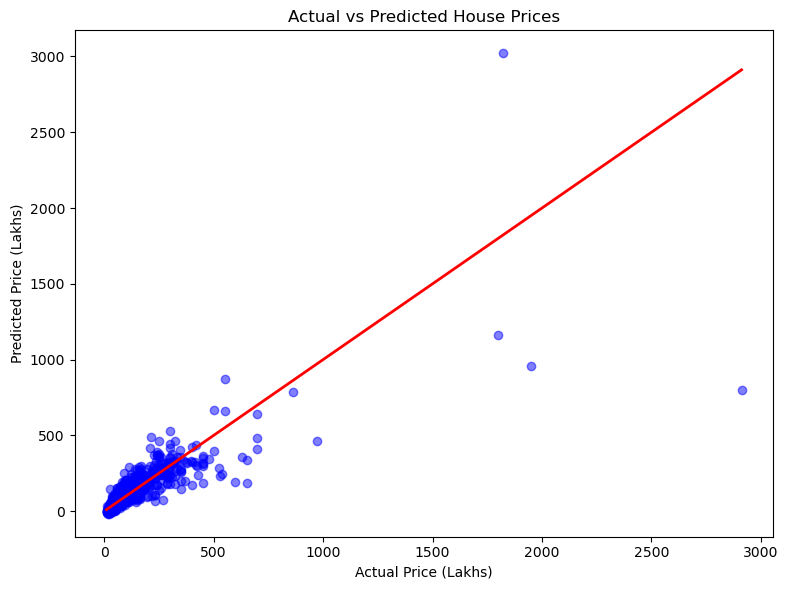

In [49]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)

plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title('Actual vs Predicted House Prices')
plt.tight_layout()
plt.show()

# 1️⃣ Try Ridge/Lasso/Random Forest to improve accuracy

# 1️⃣ Ridge Regression

In [51]:
from sklearn.linear_model import Ridge

# Create and Train
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# Predict
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate
r2_ridge  = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"Ridge R2 Score : {r2_ridge:.4f}")
print(f"Ridge MAE      : {mae_ridge:.2f} Lakhs")
print(f"Ridge RMSE     : {rmse_ridge:.2f} Lakhs")

Ridge R2 Score : 0.6418
Ridge MAE      : 26.15 Lakhs
Ridge RMSE     : 75.83 Lakhs


# 2️⃣ Lasso Regression

In [52]:
from sklearn.linear_model import Lasso

# Create and Train
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)

# Predict
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate
r2_lasso   = r2_score(y_test, y_pred_lasso)
mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print(f"Lasso R2 Score : {r2_lasso:.4f}")
print(f"Lasso MAE      : {mae_lasso:.2f} Lakhs")
print(f"Lasso RMSE     : {rmse_lasso:.2f} Lakhs")

Lasso R2 Score : 0.5807
Lasso MAE      : 29.21 Lakhs
Lasso RMSE     : 82.04 Lakhs


# 3️⃣ Random Forest

In [53]:
from sklearn.ensemble import RandomForestRegressor

# Create and Train
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
r2_rf   = r2_score(y_test, y_pred_rf)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Random Forest R2 Score : {r2_rf:.4f}")
print(f"Random Forest MAE      : {mae_rf:.2f} Lakhs")
print(f"Random Forest RMSE     : {rmse_rf:.2f} Lakhs")

Random Forest R2 Score : 0.7460
Random Forest MAE      : 21.05 Lakhs
Random Forest RMSE     : 63.84 Lakhs


# 📊 Compare All Models Together

In [54]:
# Create comparison table
comparison = pd.DataFrame({
    'Model': ['Linear Regression',
              'Ridge Regression',
              'Lasso Regression',
              'Random Forest'],

    'R2 Score': [r2, r2_ridge, r2_lasso, r2_rf],
    'MAE'     : [mae, mae_ridge, mae_lasso, mae_rf],
    'RMSE'    : [rmse, rmse_ridge, rmse_lasso, rmse_rf]
})

print(comparison)

               Model  R2 Score        MAE       RMSE
0  Linear Regression  0.643672  26.219417  75.624293
1   Ridge Regression  0.641776  26.152577  75.825197
2   Lasso Regression  0.580672  29.207160  82.037596
3      Random Forest  0.746037  21.047062  63.844152


# 📊 Visualize Comparison

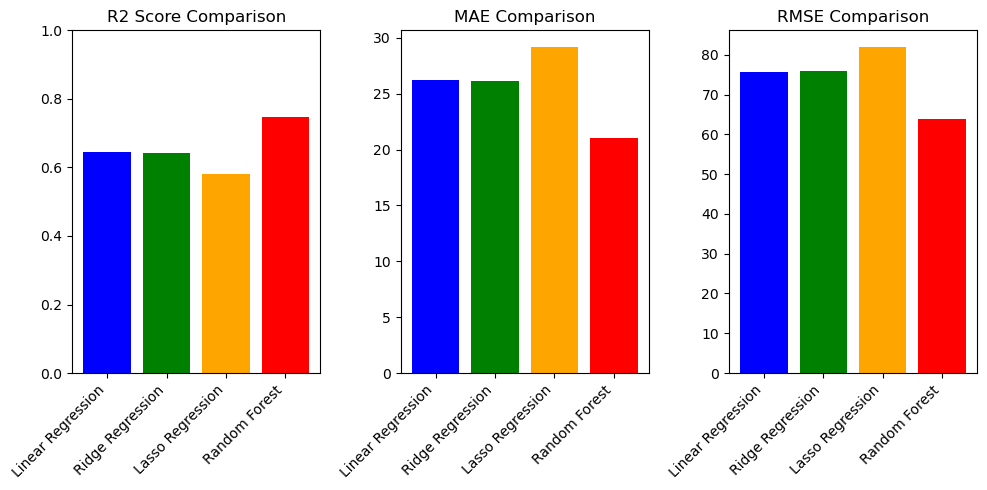

In [55]:
plt.figure(figsize=(10, 5))

# R2 Score Bar Chart
plt.subplot(1, 3, 1)
plt.bar(comparison['Model'], comparison['R2 Score'],
        color=['blue','green','orange','red'])
plt.title('R2 Score Comparison')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)

# MAE Bar Chart
plt.subplot(1, 3, 2)
plt.bar(comparison['Model'], comparison['MAE'],
        color=['blue','green','orange','red'])
plt.title('MAE Comparison')
plt.xticks(rotation=45, ha='right')

# RMSE Bar Chart
plt.subplot(1, 3, 3)
plt.bar(comparison['Model'], comparison['RMSE'],
        color=['blue','green','orange','red'])
plt.title('RMSE Comparison')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# 🚀 Can We Do Even Better?
✅ Tune Random Forest (Hyperparameter Tuning)

In [56]:
from sklearn.ensemble import RandomForestRegressor

# Try with more trees and better settings
rf_model_v2 = RandomForestRegressor(
    n_estimators=200,    # More trees
    max_depth=20,        # Control tree depth
    min_samples_split=5, # Min samples to split
    min_samples_leaf=2,  # Min samples at leaf
    random_state=42
)

rf_model_v2.fit(X_train, y_train)
y_pred_rf_v2 = rf_model_v2.predict(X_test)

r2_rf_v2   = r2_score(y_test, y_pred_rf_v2)
mae_rf_v2  = mean_absolute_error(y_test, y_pred_rf_v2)
rmse_rf_v2 = np.sqrt(mean_squared_error(y_test, y_pred_rf_v2))

print(f"Tuned Random Forest R2 Score : {r2_rf_v2:.4f}")
print(f"Tuned Random Forest MAE      : {mae_rf_v2:.2f} Lakhs")
print(f"Tuned Random Forest RMSE     : {rmse_rf_v2:.2f} Lakhs")

Tuned Random Forest R2 Score : 0.7386
Tuned Random Forest MAE      : 22.38 Lakhs
Tuned Random Forest RMSE     : 64.77 Lakhs


## ✅ Final Comparison Table

In [58]:
final_comparison = pd.DataFrame({
    'Model': ['Linear Regression',
              'Ridge Regression',
              'Lasso Regression',
              'Random Forest',
              'Tuned Random Forest'],

    'R2 Score': [r2, r2_ridge, r2_lasso, r2_rf, r2_rf_v2],
    'MAE'     : [mae, mae_ridge, mae_lasso, mae_rf, mae_rf_v2],
    'RMSE'    : [rmse, rmse_ridge, rmse_lasso, rmse_rf, rmse_rf_v2]
})

print(final_comparison)

                 Model  R2 Score        MAE       RMSE
0    Linear Regression  0.643672  26.219417  75.624293
1     Ridge Regression  0.641776  26.152577  75.825197
2     Lasso Regression  0.580672  29.207160  82.037596
3        Random Forest  0.746037  21.047062  63.844152
4  Tuned Random Forest  0.738631  22.381517  64.768402


## ✅ Predict with Best Model (Random Forest)

In [59]:
def predict_price_rf(location, total_sqft, bath, bhk):

    # Create input array with zeros
    x = np.zeros(len(X.columns))

    # Fill known values
    x[0] = total_sqft
    x[1] = bath
    x[2] = bhk

    # Fill location dummy
    if location in X.columns:
        loc_index = X.columns.get_loc(location)
        x[loc_index] = 1

    # Predict using Random Forest
    predicted_price = rf_model.predict([x])[0]

    return round(predicted_price, 2)

# Test Predictions
print(predict_price_rf('Whitefield', 1200, 2, 2))
print(predict_price_rf('Sarjapur  Road', 1500, 3, 3))
print(predict_price_rf('Electronic City', 1000, 2, 2))

47.42
84.81
29.19


In [60]:
import pickle

# Save trained model
pickle.dump(rf_model, open("house_price_model.pkl", "wb"))

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [61]:
# Save column names
pickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))

print("✅ Columns saved successfully!")

✅ Columns saved successfully!
